# Generator

表单设置 `&INPUT` 参数并运行 Generator (参数说明见 ASTRA 手册第 7 章)。
发射度 Nemit_x 单位 "π mm mrad", 数值上即 mm·mrad。

In [1]:
%run _bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
from astra_tools.widgets.forms import namelist_form
from astra_tools.namelist.parse import parse_namelists

COMMON_PARAMS = [
    "FNAME", "IPart", "Species", "Q_total", "Probe", "Noise_reduc",
    "Cathode", "Ref_Ekin", "Ref_zpos", "Ref_clock",
    "Dist_z", "sig_z", "C_sig_z", "sig_clock",
    "Dist_pz", "sig_Ekin", "cor_Ekin",
    "Dist_x", "sig_x", "Dist_y", "sig_y",
    "Dist_px", "Nemit_x", "Dist_py", "Nemit_y",
]
# 以 Manual Example 的成熟参数作为初始值 (开箱即用)
_seed = parse_namelists(PROJECT_ROOT / "examples/Manual_Example/generator.in")
gen_wmap, get_gen_params = namelist_form("INPUT", values=_seed.get("INPUT", {}), only=COMMON_PARAMS)
print("修改上方表单后运行下一个单元格。")

HTML(value='<h3>&amp;INPUT</h3>')

修改上方表单后运行下一个单元格。


In [3]:
# 生成 generator.in 并运行
from astra_tools.namelist.write import write_input_deck
from astra_tools.run import run_program

params = get_gen_params()
params["FNAME"] = "'bunch.ini'"
write_input_deck({"INPUT": params}, SIM_DIR / "generator.in",
                 header="generated by astra-notebook (01_generator)")
print("generator.in 已写入:", SIM_DIR / "generator.in")
run_program(GENERATOR_EXE, SIM_DIR, input_file="generator.in", timeout=300)
print("Generator 运行完成。")

generator.in 已写入: /Users/yuxinwu/my_projects/astra_notebook/data/workspace/generator.in
 --------------------------------------------------------------------------

                              generator              
               Version 1.0 - macOS 64bit - Apple Silicon
                        DESY,  Hamburg 2002          
                        Tue Aug 18 15:19:00 

     Working File is:    generator.in                                      
     Initializing        500      electrons
     including 6 probe particles at standard positions
     Particles are quasi randomly distributed

     Final check:
     Particles taken into account      N =        500
     total charge                      Q =     -1.000     nC
     horizontal beam position          x =     2.9867E-04 mm
     vertical beam position            y =     1.6453E-04 mm
     longitudinal beam position        z =     8.5535E-08 m
     horizontal beam size          sig x =     0.7499     mm
     vertical beam size   

输出分布文件: /Users/yuxinwu/my_projects/astra_notebook/data/workspace/bunch.ini


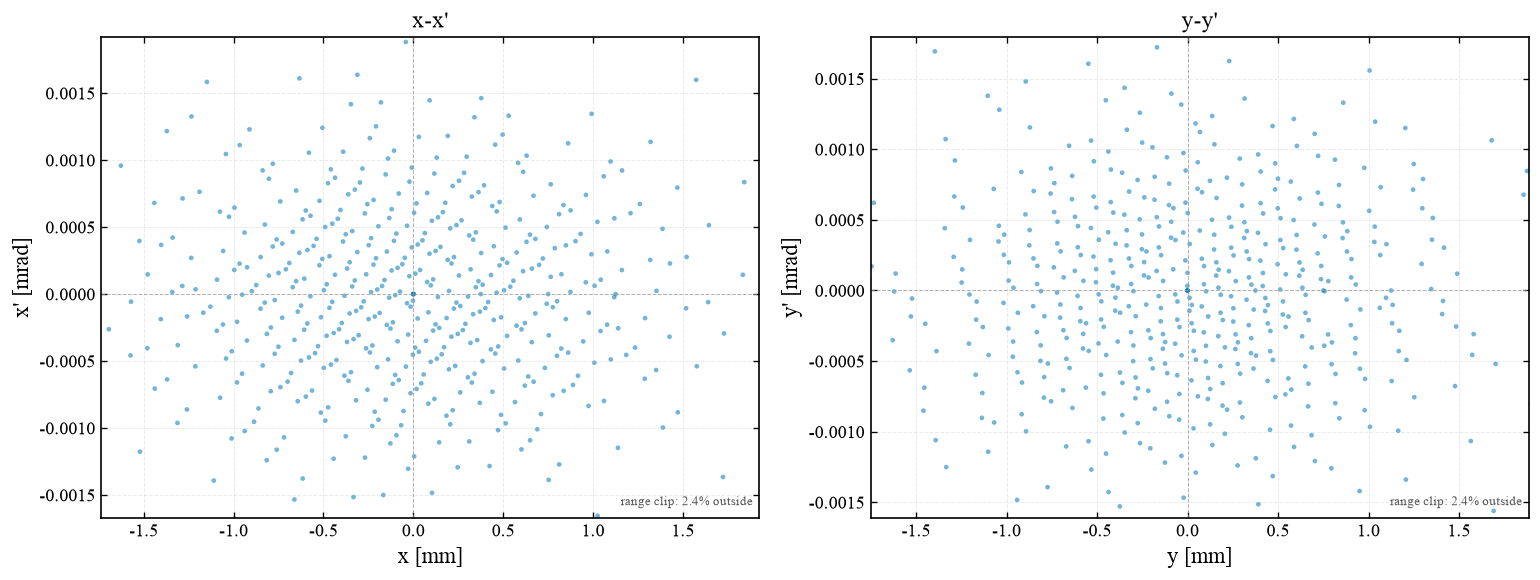

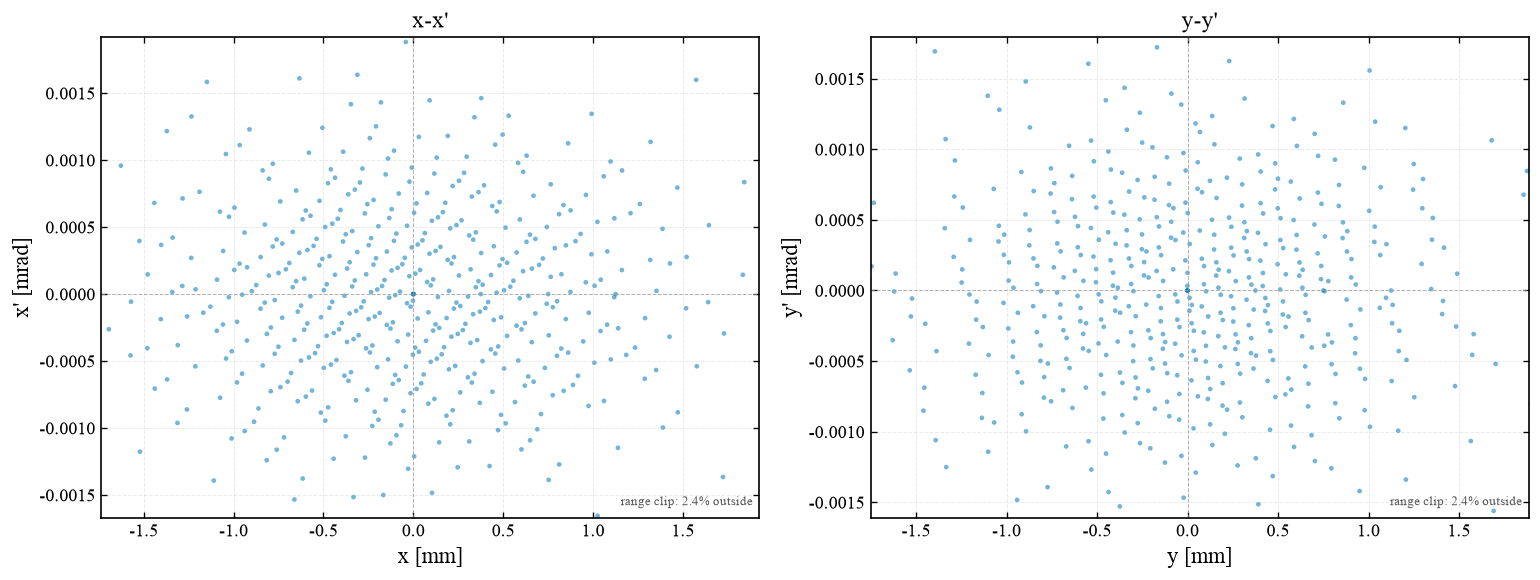

In [4]:
# 束团预览: 概要 + 统计表 + 相空间图
from astra_tools.io import read_distribution
from astra_tools.analysis.statistics import compute_statistics
from astra_tools.widgets.panels import distribution_summary_html, stats_table_html
from astra_tools.plot.phase_space import plot_transverse_phase_space

_ini = sorted(SIM_DIR.glob("*.ini"))
print("输出分布文件:", _ini[-1] if _ini else "未找到")
dist = read_distribution(_ini[-1])
distribution_summary_html(dist)
stats_table_html(compute_statistics(dist))
plot_transverse_phase_space(dist)

下一步: `02_astra.ipynb` (追踪设置 + 运行)。